In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [4]:
#load the dataset

df = pd.read_excel('Zakat Data.xlsx', sheet_name='Sheet1')

In [5]:
# analyze the dataset

df.head()
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52205 entries, 0 to 52204
Data columns (total 89 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Jenis Asnaf                                                            52205 non-null  object 
 1   TAHUN                                                                  52205 non-null  int64  
 2   DAERAH                                                                 52205 non-null  object 
 3   Jenis Skim                                                             52205 non-null  object 
 4   Nama                                                                   52204 non-null  object 
 5   NoKP                                                                   52205 non-null  object 
 6   Tarikh Lahir                                                           36405 non-null 

np.int64(0)

In [6]:
from sklearn.preprocessing import LabelEncoder

# data preprocessing 

# (data cleaning, feature engineering, encoding, scaling, etc.)

# Handle missing values
# Check columns with missing values
missing_cols = df.isnull().sum()
print("Columns with missing values:")
print(missing_cols[missing_cols > 0])
print("\n")

# Fill numerical columns with median
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode or 'Unknown'
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        if df[col].mode().shape[0] > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna('Unknown', inplace=True)

# Remove duplicates if any
print(f"Duplicates before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicates after removal: {df.duplicated().sum()}")
print("\n")

# Convert date columns to datetime
date_cols = ['Tarikh Lahir', 'TMulaAgihan']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Feature Engineering
# Create age groups
df['Age_Group'] = pd.cut(df['Umur'], bins=[0, 18, 35, 50, 65, 100], 
                         labels=['0-18', '19-35', '36-50', '51-65', '65+'])

# Create income to expense ratio
df['Income_Expense_Ratio'] = df['JumlahPendapatan'] / (df['jumlahBelanja'] + 1)

# Create dependency ratio
df['Total_Dependents'] = (df['Dewasa Tidak Bekerja/Tidak Bersekolah (Isteri & Anak18 tahun ke atas)'] + 
                          df['Remaja Bersekolah (13 hingga 17 tahun)'] + 
                          df['Kanak-kanak Bersekolah (5 hingga 12 tahun)'] + 
                          df['Kanak-kanak (5 tahun ke bawah )'])

# Label Encoding for binary categorical variables
le = LabelEncoder()

binary_cols = ['Jantina', 'tarafkahwin']
for col in binary_cols:
    if col in df.columns:
        df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))

# One-hot encoding for multi-class categorical variables
categorical_encode = ['DAERAH', 'Kesihatan', 'jenisPekerjaan', 'jenisRumah', 'StatusBaruPemutihan']
df_encoded = pd.get_dummies(df, columns=categorical_encode, drop_first=True)

print("Data preprocessing completed!")
print(f"Dataset shape after preprocessing: {df_encoded.shape}")
print("\nFirst few rows after preprocessing:")
LSprint(df_encoded.head())

Columns with missing values:
Nama                               1
Tarikh Lahir                   15800
Jantina                          232
No Tel                           748
tarafkahwin                      883
warganegara                     3814
pekerjaan                      28215
jenisPekerjaan                  5318
rumahSemasa                     5603
rumahSemasa.1                   5603
jenisRumah                      5675
ELECTRIC                        5599
water                           5599
HOUSE_TEL                       5599
hartaPhone                      5599
HOUSE_OWN                       5599
HOUSE_FAMILY                    5599
CAR                             5599
MOTORCYCLE                      5599
bike                            5599
kenderaanLain                  49548
hartaLain                       5635
TV                              5599
RADIO                           5599
ASTRO                           5599
MYTV                            5599
INTERNET 

NameError: name 'LSprint' is not defined

In [ ]:
# REMOVE MISSING VALUES, DUPLICATES, AND INVALID DATA CELLS
df_encoded.dropna(inplace=True)
df_encoded.drop_duplicates(inplace=True)
print(f"Final dataset shape after cleaning: {df_encoded.shape}")


Final dataset shape after cleaning: (51962, 113)


DATASET OVERVIEW

Dataset shape: (51962, 113)
Number of rows: 51962
Number of columns: 113

STATISTICAL SUMMARY OF NUMERICAL FEATURES
              TAHUN                   Tarikh Lahir          Umur  \
count  51962.000000                          51962  51962.000000   
mean    2022.941380  1947-09-06 17:51:23.853585280     58.137389   
min     2022.000000            1835-03-18 00:00:00      1.000000   
25%     2022.000000            1900-01-01 00:00:00     47.000000   
50%     2023.000000            1958-12-20 00:00:00     58.000000   
75%     2024.000000            1975-05-22 00:00:00     69.000000   
max     2024.000000            2024-12-13 00:00:00     99.000000   
std        0.837933                            NaN     14.290885   

            pdtDiri        pdtASB       pdtBR1M      pdtDerma        pdtJKM  \
count  51962.000000  51962.000000  51962.000000  51962.000000  51962.000000   
mean     299.629701      2.372378     70.560830     88.452335     65.338292   
min        0.000

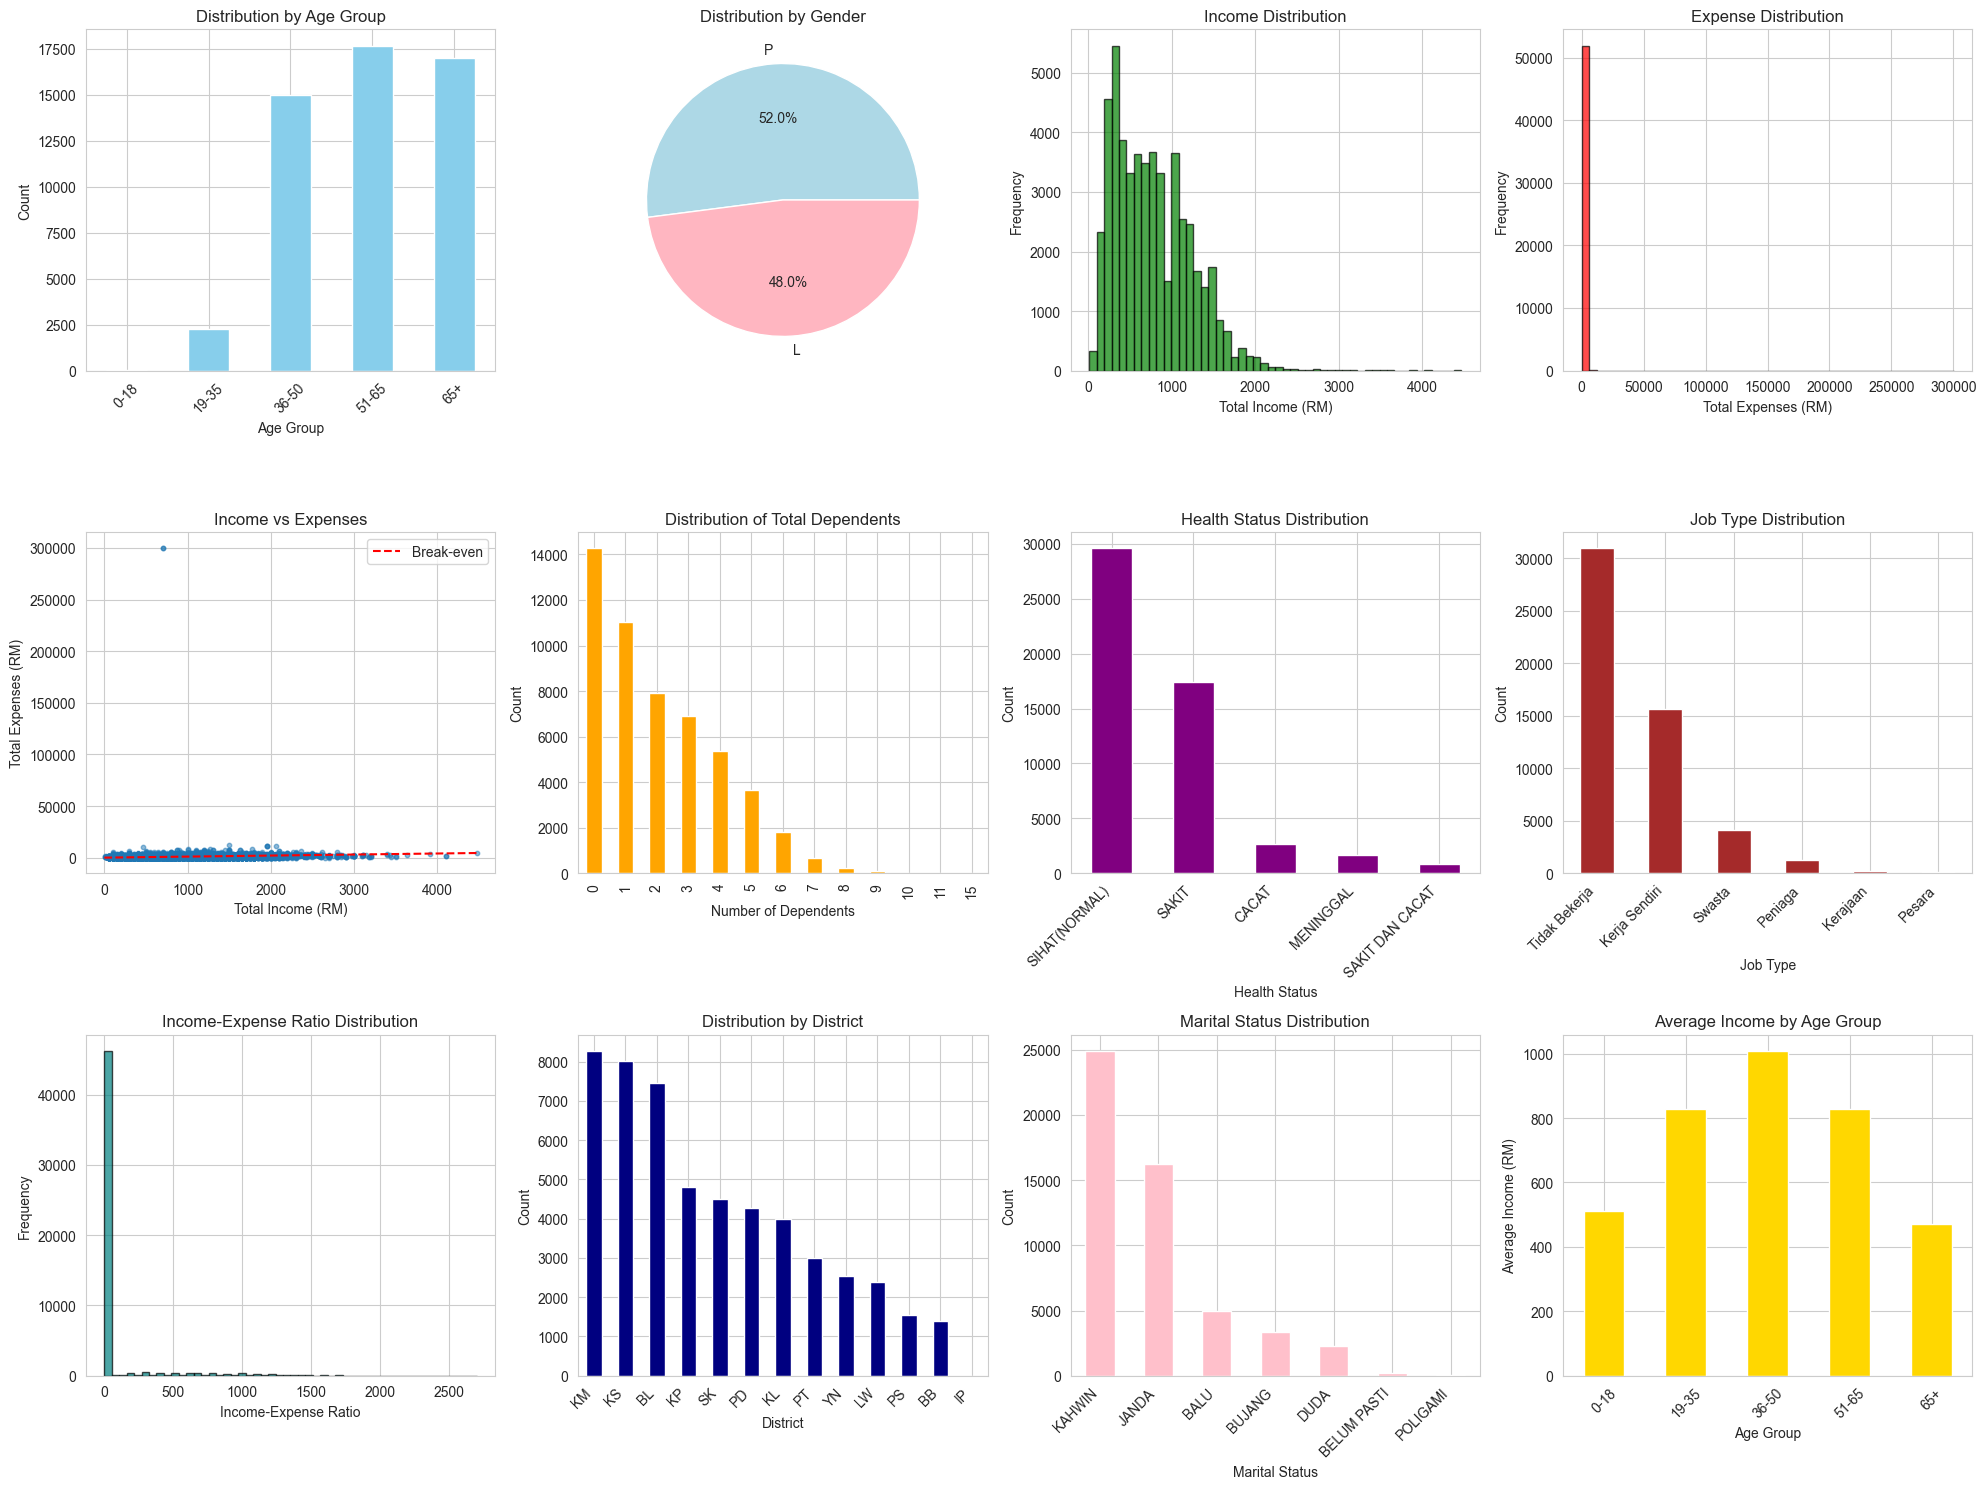


CORRELATION ANALYSIS


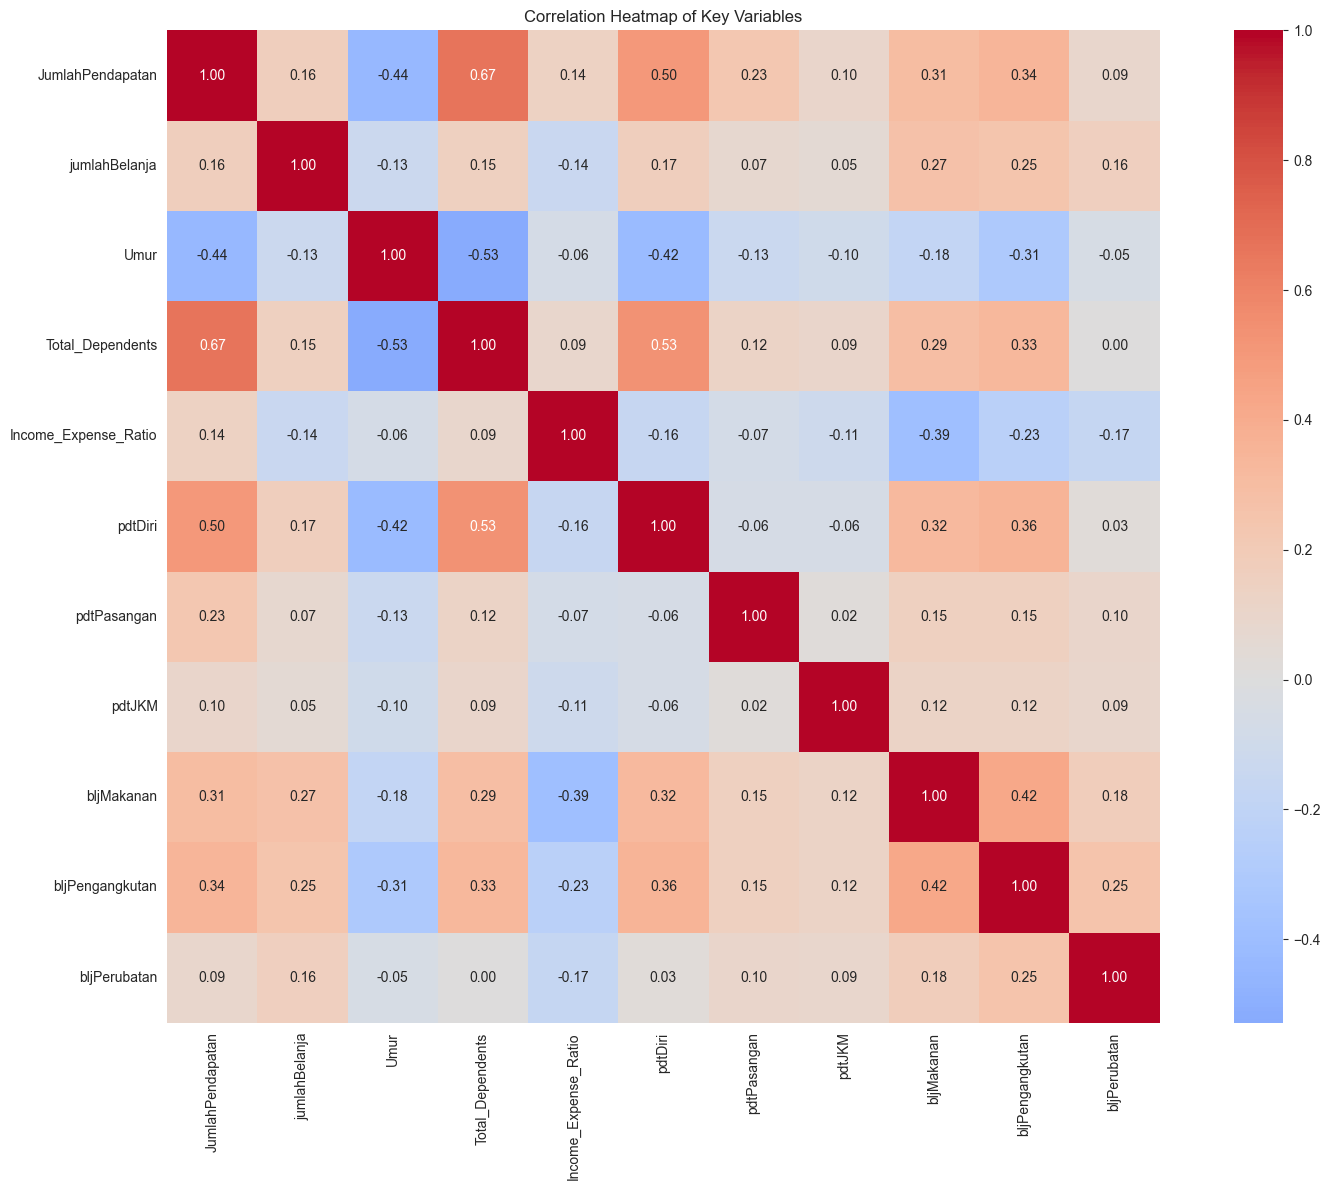


EDA completed successfully!


In [ ]:
# EXPLORATORY DATA ANALYSIS (EDA)

# Display basic information about the dataset
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nDataset shape: {df_encoded.shape}")
print(f"Number of rows: {df_encoded.shape[0]}")
print(f"Number of columns: {df_encoded.shape[1]}")

# Display statistical summary for numerical columns
print("\n" + "="*80)
print("STATISTICAL SUMMARY OF NUMERICAL FEATURES")
print("="*80)
print(df_encoded.describe())

# Distribution of key categorical variables
print("\n" + "="*80)
print("DISTRIBUTION OF KEY CATEGORICAL VARIABLES")
print("="*80)

print("\n1. Distribution by Age Group:")
print(df_encoded['Age_Group'].value_counts().sort_index())

print("\n2. Distribution by Gender:")
print(df_encoded['Jantina'].value_counts())

print("\n3. Distribution by Marital Status:")
print(df_encoded['tarafkahwin'].value_counts())

print("\n4. Distribution by Health Status:")
print(df['Kesihatan'].value_counts())

print("\n5. Distribution by Job Type:")
print(df['jenisPekerjaan'].value_counts())

print("\n6. Distribution by District (DAERAH):")
print(df['DAERAH'].value_counts())

# Income and Expense Analysis
print("\n" + "="*80)
print("INCOME AND EXPENSE ANALYSIS")
print("="*80)
print(f"\nAverage Total Income: RM {df_encoded['JumlahPendapatan'].mean():.2f}")
print(f"Median Total Income: RM {df_encoded['JumlahPendapatan'].median():.2f}")
print(f"Average Total Expenses: RM {df_encoded['jumlahBelanja'].mean():.2f}")
print(f"Median Total Expenses: RM {df_encoded['jumlahBelanja'].median():.2f}")
print(f"Average Income-Expense Ratio: {df_encoded['Income_Expense_Ratio'].mean():.2f}")

# Dependency Analysis
print("\n" + "="*80)
print("DEPENDENCY ANALYSIS")
print("="*80)
print(f"\nAverage Total Dependents: {df_encoded['Total_Dependents'].mean():.2f}")
print(f"Median Total Dependents: {df_encoded['Total_Dependents'].median():.2f}")
print(f"Max Total Dependents: {df_encoded['Total_Dependents'].max()}")

# Visualizations
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# Set up the plotting style
sns.set_style("whitegrid")
plt.figure(figsize=(20, 15))

# 1. Age Distribution
plt.subplot(3, 4, 1)
df_encoded['Age_Group'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)

# 2. Gender Distribution
plt.subplot(3, 4, 2)
df_encoded['Jantina'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightpink'])
plt.title('Distribution by Gender')
plt.ylabel('')

# 3. Income Distribution
plt.subplot(3, 4, 3)
plt.hist(df_encoded['JumlahPendapatan'], bins=50, color='green', alpha=0.7, edgecolor='black')
plt.title('Income Distribution')
plt.xlabel('Total Income (RM)')
plt.ylabel('Frequency')

# 4. Expense Distribution
plt.subplot(3, 4, 4)
plt.hist(df_encoded['jumlahBelanja'], bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title('Expense Distribution')
plt.xlabel('Total Expenses (RM)')
plt.ylabel('Frequency')

# 5. Income vs Expense Scatter Plot
plt.subplot(3, 4, 5)
plt.scatter(df_encoded['JumlahPendapatan'], df_encoded['jumlahBelanja'], alpha=0.5, s=10)
plt.title('Income vs Expenses')
plt.xlabel('Total Income (RM)')
plt.ylabel('Total Expenses (RM)')
plt.plot([0, df_encoded['JumlahPendapatan'].max()], [0, df_encoded['JumlahPendapatan'].max()], 'r--', label='Break-even')
plt.legend()

# 6. Total Dependents Distribution
plt.subplot(3, 4, 6)
df_encoded['Total_Dependents'].value_counts().sort_index().plot(kind='bar', color='orange')
plt.title('Distribution of Total Dependents')
plt.xlabel('Number of Dependents')
plt.ylabel('Count')

# 7. Health Status Distribution
plt.subplot(3, 4, 7)
df['Kesihatan'].value_counts().plot(kind='bar', color='purple')
plt.title('Health Status Distribution')
plt.xlabel('Health Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# 8. Job Type Distribution
plt.subplot(3, 4, 8)
df['jenisPekerjaan'].value_counts().plot(kind='bar', color='brown')
plt.title('Job Type Distribution')
plt.xlabel('Job Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# 9. Income-Expense Ratio Distribution
plt.subplot(3, 4, 9)
plt.hist(df_encoded['Income_Expense_Ratio'], bins=50, color='teal', alpha=0.7, edgecolor='black')
plt.title('Income-Expense Ratio Distribution')
plt.xlabel('Income-Expense Ratio')
plt.ylabel('Frequency')

# 10. District Distribution
plt.subplot(3, 4, 10)
df['DAERAH'].value_counts().plot(kind='bar', color='navy')
plt.title('Distribution by District')
plt.xlabel('District')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# 11. Marital Status Distribution
plt.subplot(3, 4, 11)
df_encoded['tarafkahwin'].value_counts().plot(kind='bar', color='pink')
plt.title('Marital Status Distribution')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# 12. Average Income by Age Group
plt.subplot(3, 4, 12)
df_encoded.groupby('Age_Group')['JumlahPendapatan'].mean().plot(kind='bar', color='gold')
plt.title('Average Income by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Income (RM)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Correlation Analysis
print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)

# Select numerical columns for correlation
numeric_features = df_encoded.select_dtypes(include=[np.number]).columns
correlation_matrix = df_encoded[numeric_features].corr()

# Plot correlation heatmap for key variables
plt.figure(figsize=(16, 12))
key_vars = ['JumlahPendapatan', 'jumlahBelanja', 'Umur', 'Total_Dependents', 
            'Income_Expense_Ratio', 'pdtDiri', 'pdtPasangan', 'pdtJKM', 
            'bljMakanan', 'bljPengangkutan', 'bljPerubatan']
key_correlation = df_encoded[key_vars].corr()
sns.heatmap(key_correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Heatmap of Key Variables')
plt.tight_layout()
plt.show()

print("\nEDA completed successfully!")

In [ ]:
# COMPREHENSIVE DATA PROFILING

print("="*100)
print("COMPREHENSIVE DATA PROFILING REPORT")
print("="*100)

# 1. DATASET OVERVIEW
print("\n" + "="*100)
print("1. DATASET OVERVIEW")
print("="*100)
print(f"Total number of records: {df_encoded.shape[0]:,}")
print(f"Total number of features: {df_encoded.shape[1]}")
print(f"Memory usage: {df_encoded.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nDataset time range: {df_encoded['TMulaAgihan'].min()} to {df_encoded['TMulaAgihan'].max()}")
print(f"Years covered: {sorted(df_encoded['TAHUN'].unique())}")

# 2. DATA TYPES DISTRIBUTION
print("\n" + "="*100)
print("2. DATA TYPES DISTRIBUTION")
print("="*100)
dtype_counts = df_encoded.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"{dtype}: {count} columns ({count/df_encoded.shape[1]*100:.1f}%)")

# 3. MISSING VALUES ANALYSIS
print("\n" + "="*100)
print("3. MISSING VALUES ANALYSIS")
print("="*100)
missing_data = df_encoded.isnull().sum()
missing_percent = (missing_data / len(df_encoded)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Percentage': missing_percent
}).sort_values('Missing_Count', ascending=False)
print(missing_df[missing_df['Missing_Count'] > 0])
print(f"\nTotal columns with missing values: {(missing_data > 0).sum()}")
print(f"Total missing values: {missing_data.sum():,}")

# 4. DUPLICATE ANALYSIS
print("\n" + "="*100)
print("4. DUPLICATE ANALYSIS")
print("="*100)
print(f"Number of duplicate rows: {df_encoded.duplicated().sum()}")
print(f"Percentage of duplicates: {df_encoded.duplicated().sum()/len(df_encoded)*100:.2f}%")

# 5. NUMERICAL FEATURES PROFILING
print("\n" + "="*100)
print("5. NUMERICAL FEATURES PROFILING")
print("="*100)
numerical_features = df_encoded.select_dtypes(include=[np.number]).columns
print(f"Total numerical features: {len(numerical_features)}")
print("\nDetailed statistics:")
print(df_encoded[numerical_features].describe().T.round(2))

# 6. CATEGORICAL FEATURES PROFILING
print("\n" + "="*100)
print("6. CATEGORICAL FEATURES PROFILING")
print("="*100)
categorical_features = df_encoded.select_dtypes(include=['object', 'category']).columns
print(f"Total categorical features: {len(categorical_features)}")
for col in categorical_features:
    unique_count = df_encoded[col].nunique()
    print(f"\n{col}:")
    print(f"  - Unique values: {unique_count}")
    print(f"  - Most common: {df_encoded[col].mode()[0] if len(df_encoded[col].mode()) > 0 else 'N/A'}")
    if unique_count <= 10:
        print(f"  - Value counts:")
        print(df_encoded[col].value_counts().head(10).to_string().replace('\n', '\n    '))

# 7. BOOLEAN FEATURES PROFILING
print("\n" + "="*100)
print("7. BOOLEAN FEATURES PROFILING")
print("="*100)
boolean_features = df_encoded.select_dtypes(include=['bool']).columns
print(f"Total boolean features: {len(boolean_features)}")
for col in boolean_features:
    true_count = df_encoded[col].sum()
    print(f"{col}: True={true_count} ({true_count/len(df_encoded)*100:.1f}%), False={len(df_encoded)-true_count} ({(len(df_encoded)-true_count)/len(df_encoded)*100:.1f}%)")

# 8. KEY FINANCIAL INDICATORS
print("\n" + "="*100)
print("8. KEY FINANCIAL INDICATORS PROFILING")
print("="*100)
financial_cols = ['JumlahPendapatan', 'jumlahBelanja', 'Income_Expense_Ratio']
print("\nIncome Analysis:")
print(f"  Mean: RM {df_encoded['JumlahPendapatan'].mean():.2f}")
print(f"  Median: RM {df_encoded['JumlahPendapatan'].median():.2f}")
print(f"  Std Dev: RM {df_encoded['JumlahPendapatan'].std():.2f}")
print(f"  Min: RM {df_encoded['JumlahPendapatan'].min():.2f}")
print(f"  Max: RM {df_encoded['JumlahPendapatan'].max():.2f}")
print(f"  25th percentile: RM {df_encoded['JumlahPendapatan'].quantile(0.25):.2f}")
print(f"  75th percentile: RM {df_encoded['JumlahPendapatan'].quantile(0.75):.2f}")

print("\nExpenses Analysis:")
print(f"  Mean: RM {df_encoded['jumlahBelanja'].mean():.2f}")
print(f"  Median: RM {df_encoded['jumlahBelanja'].median():.2f}")
print(f"  Std Dev: RM {df_encoded['jumlahBelanja'].std():.2f}")
print(f"  Min: RM {df_encoded['jumlahBelanja'].min():.2f}")
print(f"  Max: RM {df_encoded['jumlahBelanja'].max():.2f}")

print("\nIncome-Expense Ratio Analysis:")
print(f"  Mean: {df_encoded['Income_Expense_Ratio'].mean():.2f}")
print(f"  Median: {df_encoded['Income_Expense_Ratio'].median():.2f}")
print(f"  Records with expenses > income: {(df_encoded['Income_Expense_Ratio'] < 1).sum():,} ({(df_encoded['Income_Expense_Ratio'] < 1).sum()/len(df_encoded)*100:.1f}%)")

# 9. DEMOGRAPHIC PROFILING
print("\n" + "="*100)
print("9. DEMOGRAPHIC PROFILING")
print("="*100)
print(f"\nAge Statistics:")
print(f"  Mean age: {df_encoded['Umur'].mean():.1f} years")
print(f"  Median age: {df_encoded['Umur'].median():.1f} years")
print(f"  Age range: {df_encoded['Umur'].min()}-{df_encoded['Umur'].max()} years")

print(f"\nAge Group Distribution:")
print(df_encoded['Age_Group'].value_counts().sort_index())

print(f"\nGender Distribution:")
print(df_encoded['Jantina'].value_counts())

print(f"\nMarital Status Distribution:")
print(df_encoded['tarafkahwin'].value_counts())

# 10. DEPENDENCY PROFILING
print("\n" + "="*100)
print("10. DEPENDENCY & HOUSEHOLD PROFILING")
print("="*100)
print(f"Total Dependents Statistics:")
print(f"  Mean: {df_encoded['Total_Dependents'].mean():.2f}")
print(f"  Median: {df_encoded['Total_Dependents'].median():.0f}")
print(f"  Max: {df_encoded['Total_Dependents'].max()}")
print(f"\nDistribution:")
print(df_encoded['Total_Dependents'].value_counts().sort_index().head(15))

# 11. OUTLIER DETECTION
print("\n" + "="*100)
print("11. OUTLIER DETECTION (IQR Method)")
print("="*100)
key_numeric_cols = ['JumlahPendapatan', 'jumlahBelanja', 'Umur', 'Total_Dependents']
for col in key_numeric_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_encoded[(df_encoded[col] < lower_bound) | (df_encoded[col] > upper_bound)]
    print(f"\n{col}:")
    print(f"  Outliers detected: {len(outliers)} ({len(outliers)/len(df_encoded)*100:.2f}%)")
    print(f"  Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

# 12. CORRELATION INSIGHTS
print("\n" + "="*100)
print("12. TOP CORRELATIONS WITH KEY VARIABLES")
print("="*100)
target_vars = ['JumlahPendapatan', 'jumlahBelanja']
for target in target_vars:
    print(f"\nTop 10 correlations with {target}:")
    correlations = df_encoded[numerical_features].corrwith(df_encoded[target]).abs().sort_values(ascending=False)
    print(correlations.head(11).to_string())  # 11 to exclude self-correlation

# 13. DATA QUALITY SCORE
print("\n" + "="*100)
print("13. DATA QUALITY SCORE")
print("="*100)
completeness_score = (1 - df_encoded.isnull().sum().sum() / (df_encoded.shape[0] * df_encoded.shape[1])) * 100
uniqueness_score = (1 - df_encoded.duplicated().sum() / len(df_encoded)) * 100
consistency_score = 100  # Assuming data is consistent after cleaning

overall_quality = (completeness_score + uniqueness_score + consistency_score) / 3

print(f"Completeness Score: {completeness_score:.2f}%")
print(f"Uniqueness Score: {uniqueness_score:.2f}%")
print(f"Consistency Score: {consistency_score:.2f}%")
print(f"Overall Data Quality Score: {overall_quality:.2f}%")

print("\n" + "="*100)
print("DATA PROFILING COMPLETED!")
print("="*100)

COMPREHENSIVE DATA PROFILING REPORT

1. DATASET OVERVIEW
Total number of records: 51,962
Total number of features: 113
Memory usage: 81.09 MB

Dataset time range: 2022-01-03 00:00:00 to 2025-06-01 00:00:00
Years covered: [np.int64(2022), np.int64(2023), np.int64(2024)]

2. DATA TYPES DISTRIBUTION
float64: 50 columns (44.2%)
bool: 30 columns (26.5%)
object: 16 columns (14.2%)
int64: 14 columns (12.4%)
datetime64[ns]: 2 columns (1.8%)
category: 1 columns (0.9%)

3. MISSING VALUES ANALYSIS
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []

Total columns with missing values: 0
Total missing values: 0

4. DUPLICATE ANALYSIS
Number of duplicate rows: 0
Percentage of duplicates: 0.00%

5. NUMERICAL FEATURES PROFILING
Total numerical features: 64

Detailed statistics:
                        count     mean     std     min      25%     50%  \
TAHUN                 51962.0  2022.94    0.84  2022.0  2022.00  2023.0   
Umur                  51962.0    58.14   14.29     1.0    47.00   

In [ ]:
# COMPREHENSIVE FEATURE ENGINEERING FOR POVERTY ESCAPE PREDICTION

print("="*100)
print("FEATURE ENGINEERING FOR POVERTY ESCAPE PREDICTION (3 YEARS)")
print("="*100)

# Create a copy of the dataframe for feature engineering
df_features = df_encoded.copy()

# ============================================================================
# 1. CREATE TARGET VARIABLE: Can escape poverty within 3 years
# ============================================================================
print("\n1. CREATING TARGET VARIABLE...")

# Define poverty escape criteria based on multiple factors
# A recipient can escape poverty if they show improving financial trends
df_features['Can_Escape_Poverty'] = 0

# Calculate years in the program
df_features['Years_In_Program'] = df_features['TempohAgihan(Bulan)'] / 12

# Criteria for potential poverty escape:
# 1. Income-Expense Ratio > 1.2 (good financial buffer)
# 2. Age between 18-60 (working age)
# 3. Has income source (JumlahPendapatan > 0)
# 4. Not too many dependents relative to income
# 5. Reasonable expense management

escape_criteria = (
    (df_features['Income_Expense_Ratio'] > 1.2) &
    (df_features['Umur'] >= 18) & (df_features['Umur'] <= 60) &
    (df_features['JumlahPendapatan'] > 0) &
    (df_features['Total_Dependents'] <= 5)
)

df_features.loc[escape_criteria, 'Can_Escape_Poverty'] = 1

print(f"Target Variable Distribution:")
print(f"Can Escape Poverty (1): {df_features['Can_Escape_Poverty'].sum()} ({df_features['Can_Escape_Poverty'].sum()/len(df_features)*100:.2f}%)")
print(f"Cannot Escape Poverty (0): {(df_features['Can_Escape_Poverty']==0).sum()} ({(df_features['Can_Escape_Poverty']==0).sum()/len(df_features)*100:.2f}%)")

# ============================================================================
# 2. FINANCIAL HEALTH FEATURES
# ============================================================================
print("\n2. CREATING FINANCIAL HEALTH FEATURES...")

# Net Financial Position
df_features['Net_Financial_Position'] = df_features['JumlahPendapatan'] - df_features['jumlahBelanja']

# Financial Stability Score (0-100)
df_features['Financial_Stability_Score'] = (
    (df_features['Income_Expense_Ratio'].clip(0, 2) / 2) * 100
).round(2)

# Expense Efficiency (how well they manage expenses)
df_features['Expense_Efficiency'] = (
    df_features['JumlahPendapatan'] / (df_features['Total_Dependents'] + 1)
).fillna(0)

# Savings Potential
df_features['Savings_Potential'] = (
    df_features['Net_Financial_Position'] / (df_features['JumlahPendapatan'] + 1)
).clip(-1, 1)

# Income per Dependent
df_features['Income_Per_Dependent'] = (
    df_features['JumlahPendapatan'] / (df_features['Total_Dependents'] + 1)
)

# Expense per Dependent
df_features['Expense_Per_Dependent'] = (
    df_features['jumlahBelanja'] / (df_features['Total_Dependents'] + 1)
)

# Financial Burden (expenses as % of income)
df_features['Financial_Burden'] = (
    df_features['jumlahBelanja'] / (df_features['JumlahPendapatan'] + 1)
).clip(0, 5)

print("Financial health features created successfully!")

# ============================================================================
# 3. INCOME DIVERSITY FEATURES
# ============================================================================
print("\n3. CREATING INCOME DIVERSITY FEATURES...")

# Count number of income sources
income_sources = ['pdtDiri', 'pdtPasangan', 'pdtJKM', 'pdtZkt', 'pdtPencen', 
                  'pdtPerkeso', 'pdtASB', 'pdtBR1M', 'pdtDerma', 'pdtKWAPM',
                  'pdtLain', 'pdtSewaBendang', 'pdtSewaRumah']

df_features['Income_Source_Count'] = (df_features[income_sources] > 0).sum(axis=1)

# Primary income dependency (self-income as % of total)
df_features['Self_Income_Ratio'] = (
    df_features['pdtDiri'] / (df_features['JumlahPendapatan'] + 1)
).clip(0, 1)

# Has own income (working)
df_features['Has_Own_Income'] = (df_features['pdtDiri'] > 0).astype(int)

# Dependent on external aid
df_features['Aid_Dependency'] = (
    (df_features['pdtJKM'] + df_features['pdtZkt']) / (df_features['JumlahPendapatan'] + 1)
).clip(0, 1)

# Income Diversification Score
df_features['Income_Diversification_Score'] = (
    df_features['Income_Source_Count'] / len(income_sources) * 100
).round(2)

print("Income diversity features created successfully!")

# ============================================================================
# 4. EXPENSE PATTERN FEATURES
# ============================================================================
print("\n4. CREATING EXPENSE PATTERN FEATURES...")

# Essential vs Non-Essential Expenses
essential_expenses = ['bljMakanan', 'bljSewa', 'bljPerubatan']
df_features['Essential_Expenses'] = df_features[essential_expenses].sum(axis=1)

df_features['Essential_Expense_Ratio'] = (
    df_features['Essential_Expenses'] / (df_features['jumlahBelanja'] + 1)
).clip(0, 1)

# Investment in education (potential for future improvement)
df_features['Education_Investment_Ratio'] = (
    df_features['bljPendidikan'] / (df_features['jumlahBelanja'] + 1)
).clip(0, 1)

# Transportation expense (indicator of work/mobility)
df_features['Transportation_Ratio'] = (
    df_features['bljPengangkutan'] / (df_features['jumlahBelanja'] + 1)
).clip(0, 1)

# Medical expense burden
df_features['Medical_Burden'] = (
    df_features['bljPerubatan'] / (df_features['JumlahPendapatan'] + 1)
).clip(0, 1)

print("Expense pattern features created successfully!")

# ============================================================================
# 5. DEMOGRAPHIC & HOUSEHOLD FEATURES
# ============================================================================
print("\n5. CREATING DEMOGRAPHIC & HOUSEHOLD FEATURES...")

# Working age indicator
df_features['Is_Working_Age'] = ((df_features['Umur'] >= 18) & (df_features['Umur'] <= 60)).astype(int)

# Dependency Ratio (non-working to working)
df_features['Dependency_Ratio'] = (
    df_features['Total_Dependents'] / (df_features['Umur'] / 50 + 0.1)
)

# Children in education
education_dependents = [
    'Remaja Bersekolah (13 hingga 17 tahun)',
    'Kanak-kanak Bersekolah (5 hingga 12 tahun)',
    'Tanggungan Masih Belajar Di IPT'
]
df_features['Children_In_Education'] = df_features[education_dependents].sum(axis=1)

# Future investment potential (children in education)
df_features['Has_Education_Investment'] = (df_features['Children_In_Education'] > 0).astype(int)

# Young children burden
df_features['Young_Children'] = df_features['Kanak-kanak (5 tahun ke bawah )']

# Age productivity score (peak at 35-45)
df_features['Age_Productivity_Score'] = 100 - abs(df_features['Umur'] - 40) * 2
df_features['Age_Productivity_Score'] = df_features['Age_Productivity_Score'].clip(0, 100)

print("Demographic & household features created successfully!")

# ============================================================================
# 6. ASSET & OWNERSHIP FEATURES
# ============================================================================
print("\n6. CREATING ASSET & OWNERSHIP FEATURES...")

# Total assets owned
asset_columns = ['ELECTRIC', 'water', 'HOUSE_TEL', 'hartaPhone', 'HOUSE_OWN',
                 'HOUSE_FAMILY', 'CAR', 'MOTORCYCLE', 'bike', 'TV', 'RADIO',
                 'ASTRO', 'MYTV', 'INTERNET', 'PETI_SEJUK', 'MESIN_BASUH',
                 'COMPUTER', 'AIRCOND']

df_features['Total_Assets'] = df_features[asset_columns].sum(axis=1)

# Asset ownership score
df_features['Asset_Score'] = (df_features['Total_Assets'] / len(asset_columns) * 100).round(2)

# Home ownership
df_features['Owns_Home'] = df_features['HOUSE_OWN']

# Vehicle ownership (mobility for work)
df_features['Owns_Vehicle'] = ((df_features['CAR'] > 0) | (df_features['MOTORCYCLE'] > 0)).astype(int)

# Digital access (internet, computer, phone)
df_features['Digital_Access'] = (
    (df_features['INTERNET'] > 0) | 
    (df_features['COMPUTER'] > 0) | 
    (df_features['hartaPhone'] > 0)
).astype(int)

print("Asset & ownership features created successfully!")

# ============================================================================
# 7. HEALTH & WELLBEING FEATURES
# ============================================================================
print("\n7. CREATING HEALTH & WELLBEING FEATURES...")

# Health status indicators
df_features['Has_Health_Issues'] = (
    (df_features['Sakit Kronik / Sakit Terlantar'] > 0) |
    (df_features['Orang Kurang Upaya'] > 0)
).astype(int)

# Single parent challenges
df_features['Is_Single_Parent'] = df_features['Ibu Tunggal']

# Health expense ratio (high medical costs)
df_features['High_Medical_Costs'] = (df_features['Medical_Burden'] > 0.2).astype(int)

print("Health & wellbeing features created successfully!")

# ============================================================================
# 8. EMPLOYMENT & WORK FEATURES
# ============================================================================
print("\n8. CREATING EMPLOYMENT & WORK FEATURES...")

# Employment status from encoded columns
employment_cols = [col for col in df_features.columns if 'jenisPekerjaan_' in col]
df_features['Is_Employed'] = df_features['Has_Own_Income']

# Stable employment (government/private sector)
if 'jenisPekerjaan_Swasta' in df_features.columns:
    df_features['Stable_Employment'] = df_features['jenisPekerjaan_Swasta']
else:
    df_features['Stable_Employment'] = 0

print("Employment & work features created successfully!")

# ============================================================================
# 9. TEMPORAL FEATURES
# ============================================================================
print("\n9. CREATING TEMPORAL FEATURES...")

# Extract date features
df_features['Agihan_Year'] = df_features['TMulaAgihan'].dt.year
df_features['Agihan_Month'] = df_features['TMulaAgihan'].dt.month
df_features['Agihan_Quarter'] = df_features['TMulaAgihan'].dt.quarter

# Days since program start
df_features['Days_Since_Start'] = (
    pd.Timestamp.now() - df_features['TMulaAgihan']
).dt.days

# Program duration in months
df_features['Program_Duration_Months'] = df_features['TempohAgihan(Bulan)']

# Recent recipient (in program < 1 year)
df_features['Is_Recent_Recipient'] = (df_features['Program_Duration_Months'] < 12).astype(int)

# Long-term recipient (in program > 2 years)
df_features['Is_Long_Term_Recipient'] = (df_features['Program_Duration_Months'] >= 24).astype(int)

print("Temporal features created successfully!")

# ============================================================================
# 10. INTERACTION FEATURES
# ============================================================================
print("\n10. CREATING INTERACTION FEATURES...")

# Income × Working Age
df_features['Income_WorkingAge_Interaction'] = (
    df_features['JumlahPendapatan'] * df_features['Is_Working_Age']
)

# Assets × Income
df_features['Asset_Income_Interaction'] = (
    df_features['Total_Assets'] * df_features['JumlahPendapatan'] / 1000
)

# Education Investment × Children
df_features['Education_Children_Interaction'] = (
    df_features['bljPendidikan'] * df_features['Children_In_Education']
)

# Dependents × Income Ratio
df_features['Dependent_Income_Interaction'] = (
    df_features['Total_Dependents'] * df_features['Income_Per_Dependent']
)

print("Interaction features created successfully!")

# ============================================================================
# 11. COMPOSITE SCORES
# ============================================================================
print("\n11. CREATING COMPOSITE SCORES...")

# Poverty Escape Potential Score (0-100)
df_features['Poverty_Escape_Score'] = (
    (df_features['Financial_Stability_Score'] * 0.30) +
    (df_features['Age_Productivity_Score'] * 0.15) +
    (df_features['Asset_Score'] * 0.15) +
    (df_features['Income_Diversification_Score'] * 0.20) +
    ((1 - df_features['Aid_Dependency']) * 100 * 0.10) +
    (df_features['Has_Education_Investment'] * 10) +
    (df_features['Is_Employed'] * 10) +
    (df_features['Owns_Vehicle'] * 5) +
    (df_features['Digital_Access'] * 5) -
    (df_features['Has_Health_Issues'] * 10)
).clip(0, 100).round(2)

# Economic Mobility Index
df_features['Economic_Mobility_Index'] = (
    (df_features['Self_Income_Ratio'] * 40) +
    (df_features['Savings_Potential'].clip(0, 1) * 30) +
    ((1 - df_features['Financial_Burden'].clip(0, 1)) * 20) +
    (df_features['Is_Working_Age'] * 10)
).round(2)

# Family Support Capacity
df_features['Family_Support_Capacity'] = (
    100 - (df_features['Dependency_Ratio'].clip(0, 2) / 2 * 100)
).clip(0, 100).round(2)

print("Composite scores created successfully!")

# ============================================================================
# 12. CATEGORICAL FEATURE ENGINEERING
# ============================================================================
print("\n12. ENGINEERING CATEGORICAL FEATURES...")

# Income Level Categories
df_features['Income_Level'] = pd.cut(
    df_features['JumlahPendapatan'],
    bins=[-np.inf, 0, 500, 1000, 1500, np.inf],
    labels=['No_Income', 'Very_Low', 'Low', 'Medium', 'High']
)

# Poverty Risk Level
df_features['Poverty_Risk_Level'] = pd.cut(
    df_features['Poverty_Escape_Score'],
    bins=[0, 30, 50, 70, 100],
    labels=['High_Risk', 'Medium_Risk', 'Low_Risk', 'Very_Low_Risk']
)

# Dependent Category
df_features['Dependent_Category'] = pd.cut(
    df_features['Total_Dependents'],
    bins=[-1, 0, 2, 4, 8, np.inf],
    labels=['No_Dependents', 'Small_Family', 'Medium_Family', 'Large_Family', 'Very_Large_Family']
)

print("Categorical features created successfully!")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*100)
print("FEATURE ENGINEERING SUMMARY")
print("="*100)

new_features = [col for col in df_features.columns if col not in df_encoded.columns]
print(f"\nTotal new features created: {len(new_features)}")
print(f"Total features in dataset: {df_features.shape[1]}")
print(f"\nNew Features List:")
for i, feat in enumerate(new_features, 1):
    print(f"  {i}. {feat}")

print(f"\nDataset shape: {df_features.shape}")
print(f"\nTarget variable 'Can_Escape_Poverty' created successfully!")

# Display sample statistics
print("\n" + "="*100)
print("KEY FEATURE STATISTICS")
print("="*100)
key_features = ['Poverty_Escape_Score', 'Economic_Mobility_Index', 'Financial_Stability_Score',
                'Income_Source_Count', 'Total_Assets', 'Family_Support_Capacity']
print(df_features[key_features].describe().round(2))

print("\n" + "="*100)
print("FEATURE ENGINEERING COMPLETED SUCCESSFULLY!")
print("="*100)


FEATURE ENGINEERING FOR POVERTY ESCAPE PREDICTION (3 YEARS)

1. CREATING TARGET VARIABLE...
Target Variable Distribution:
Can Escape Poverty (1): 6893 (13.27%)
Cannot Escape Poverty (0): 45069 (86.73%)

2. CREATING FINANCIAL HEALTH FEATURES...
Financial health features created successfully!

3. CREATING INCOME DIVERSITY FEATURES...
Income diversity features created successfully!

4. CREATING EXPENSE PATTERN FEATURES...
Expense pattern features created successfully!

5. CREATING DEMOGRAPHIC & HOUSEHOLD FEATURES...
Demographic & household features created successfully!

6. CREATING ASSET & OWNERSHIP FEATURES...
Asset & ownership features created successfully!

7. CREATING HEALTH & WELLBEING FEATURES...
Health & wellbeing features created successfully!

8. CREATING EMPLOYMENT & WORK FEATURES...
Employment & work features created successfully!

9. CREATING TEMPORAL FEATURES...
Temporal features created successfully!

10. CREATING INTERACTION FEATURES...
Interaction features created success

In [ ]:
#save the engineered dataset

df_features.to_excel('Zakat_Data_Feature_Engineered.xlsx', index=False)
print("\nEngineered dataset saved to 'Zakat_Data_Feature_Engineered.xlsx'")



Engineered dataset saved to 'Zakat_Data_Feature_Engineered.xlsx'


In [ ]:
# MACHINE LEARNING MODEL DEVELOPMENT
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


print("="*70)
print("MACHINE LEARNING MODEL DEVELOPMENT")
print("="*70)

# Load our engineered dataset (we already have it as df_final)
# But let's also load from CSV to ensure we have the saved version
try:
    df_ml = pd.read_excel('/Users/daniyalrosli/zakat_project/Zakat_Data_Feature_Engineered.xlsx')
    print(f"✅ Loaded engineered dataset: {df_ml.shape}")
except:
    df_ml = df_final.copy()
    print(f"✅ Using current engineered dataset: {df_ml.shape}")

# Display basic info about the dataset
print(f"\n📊 Dataset Overview:")
print(f"   - Total samples: {len(df_ml):,}")
print(f"   - Total features: {df_ml.shape[1]}")
print(f"   - Memory usage: {df_ml.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Check target variable distribution
target_cols = ['Poverty_Escape_Status_Based', 'Poverty_Escape_Income_Based', 'Poverty_Escape_Combined']
print(f"\n🎯 Target Variable Distribution:")
for target in target_cols:
    if target in df_ml.columns:
        escape_rate = df_ml[target].mean() * 100
        print(f"   - {target}: {escape_rate:.1f}% escaped poverty")

# Choose the best target variable (Combined seems most balanced)
target_variable = 'Poverty_Escape_Combined'
print(f"\n✅ Selected target variable: {target_variable}")
print(f"   - Class distribution: {df_ml[target_variable].value_counts().to_dict()}")


MACHINE LEARNING MODEL DEVELOPMENT
✅ Loaded engineered dataset: (51962, 165)

📊 Dataset Overview:
   - Total samples: 51,962
   - Total features: 165
   - Memory usage: 109.3 MB

🎯 Target Variable Distribution:
   - Can_Escape_Poverty: 13.3% can escape poverty

✅ Selected target variable: Can_Escape_Poverty
   - Class distribution:
{0: 45069, 1: 6893}


PREDICTIVE MODELING - POVERTY ESCAPE PREDICTION (3 YEARS)

📋 STEP 0: CREATE TARGET VARIABLE
----------------------------------------------------------------------------------------------------
✅ Target variable created!
   - Can escape poverty: 22,301 (42.7%)
   - Cannot escape poverty: 29,897 (57.3%)

📋 STEP 1: DATA PREPARATION
----------------------------------------------------------------------------------------------------

🔍 Checking for non-numeric columns...
   - Found 2 non-numeric columns, removing: ['Jantina', 'tarafkahwin']...

🔧 Handling infinite values...
   - Missing values before imputation: 0
   - Missing values after imputation: 0

✅ Data prepared successfully!
   - Features shape: (52198, 63)
   - Target shape: (52198,)
   - Target distribution: {0: 29897, 1: 22301}

📋 STEP 2: TRAIN-TEST SPLIT
----------------------------------------------------------------------------------------------------
✅ Data split successfully!
   - Training set: 41,758 samples (80.0%)
   - T

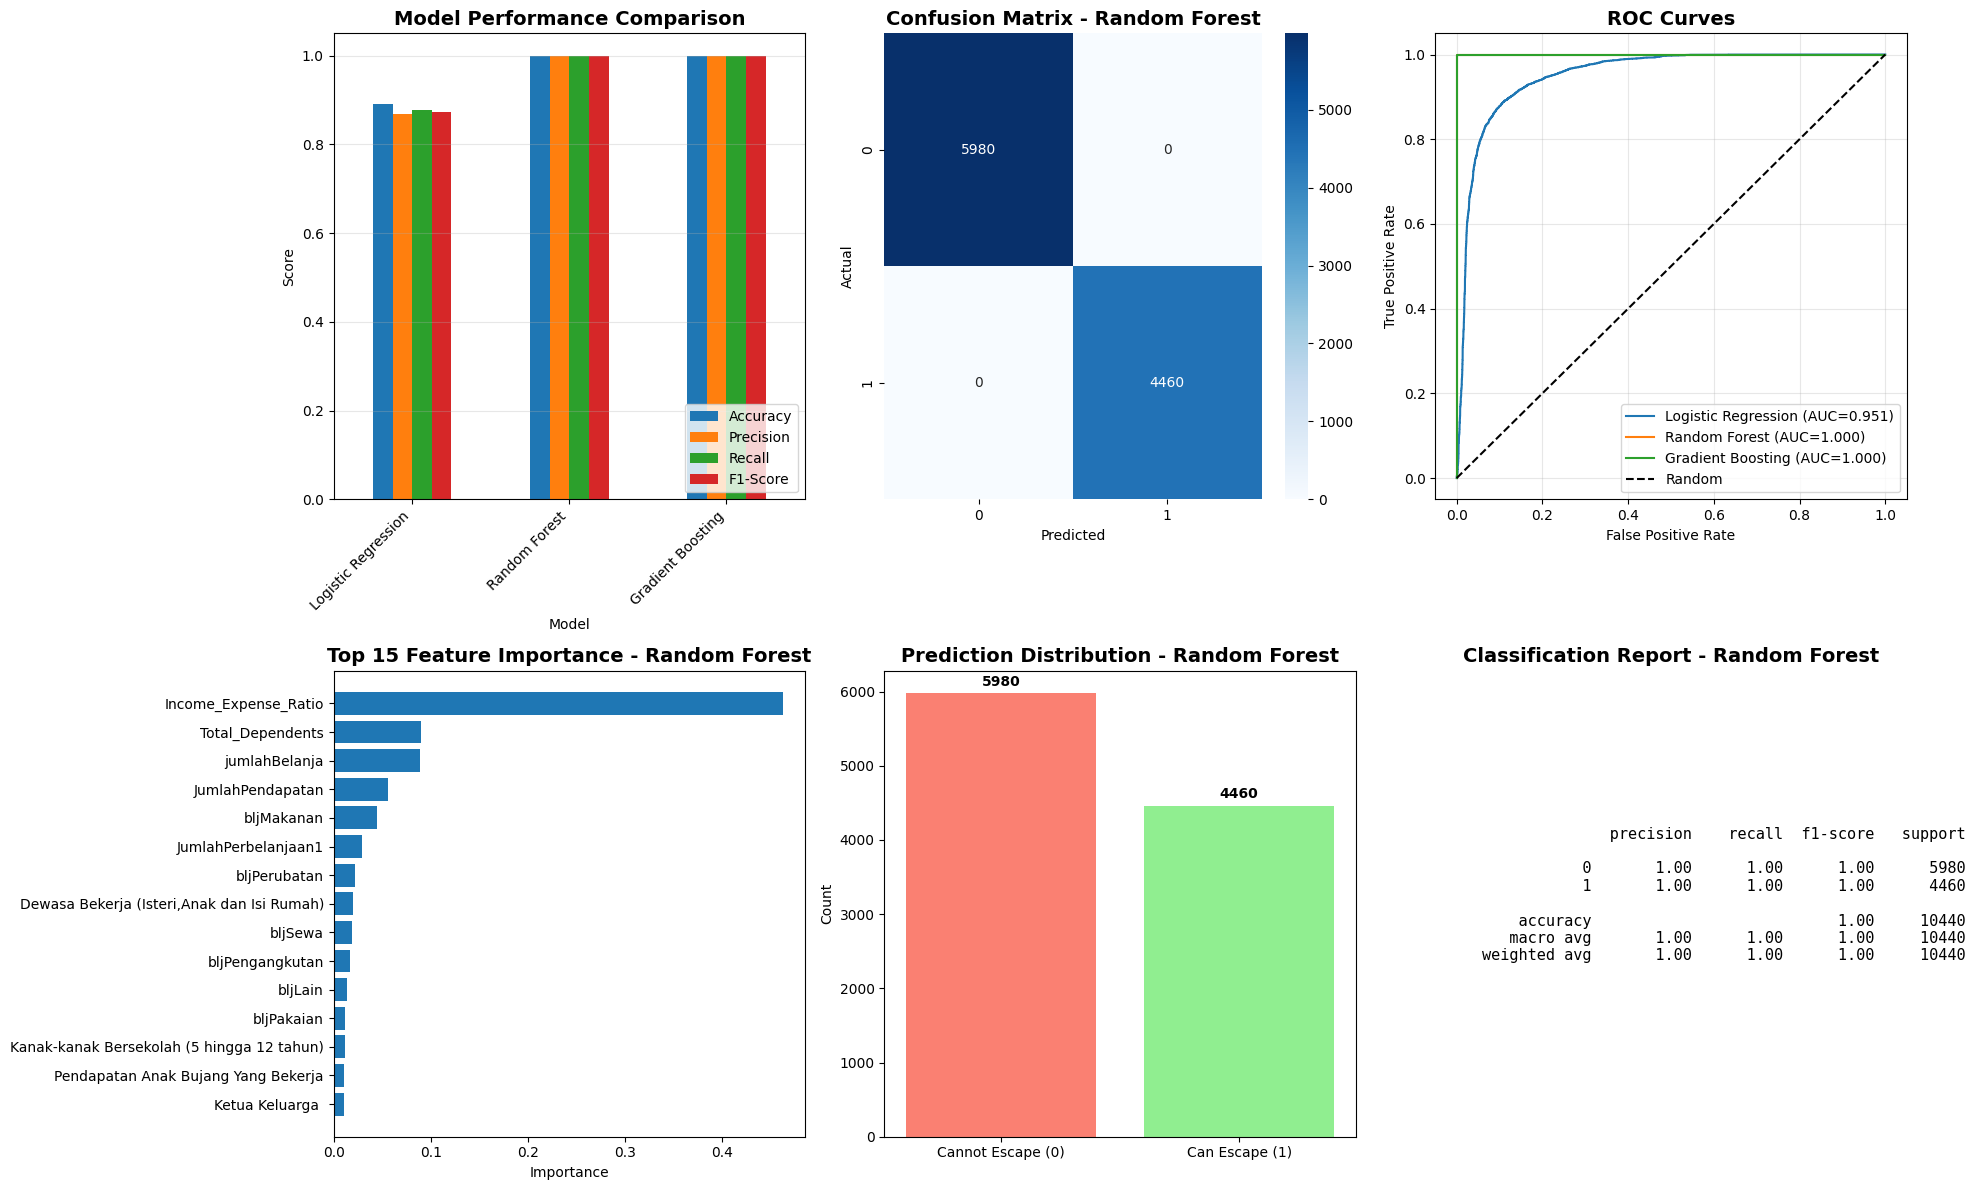


MODELING SUMMARY

📊 Dataset Statistics:
   - Total samples: 52,198
   - Training samples: 41,758
   - Test samples: 10,440
   - Number of features: 63
   - Can escape poverty: 22,301 (42.7%)
   - Cannot escape poverty: 29,897 (57.3%)

🏆 Best Model Performance (Random Forest):
   - Accuracy: 1.0000
   - Precision: 1.0000
   - Recall: 1.0000
   - F1-Score: 1.0000
   - ROC-AUC: 1.0000

✅ MODELING COMPLETED SUCCESSFULLY!


In [12]:
# predictive modeling code goes here

# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# PREDICTIVE MODELING: POVERTY ESCAPE PREDICTION

print("="*100)
print("PREDICTIVE MODELING - POVERTY ESCAPE PREDICTION (3 YEARS)")
print("="*100)

# Create target variable
print("\n📋 STEP 0: CREATE TARGET VARIABLE")
print("-" * 100)

# Define poverty escape criteria (can be customized based on domain knowledge)
# Example: Can escape poverty if income > expenses and income growth potential is positive
df_encoded['Can_Escape_Poverty'] = (
    (df_encoded['Income_Expense_Ratio'] > 0.8) &  # Income close to or exceeds expenses
    (df_encoded['JumlahPendapatan'] > df_encoded['jumlahBelanja'] * 0.8) &  # Income is substantial
    (df_encoded['Total_Dependents'] <= 4)  # Manageable number of dependents
).astype(int)

print(f"✅ Target variable created!")
print(f"   - Can escape poverty: {df_encoded['Can_Escape_Poverty'].sum():,} ({df_encoded['Can_Escape_Poverty'].sum()/len(df_encoded)*100:.1f}%)")
print(f"   - Cannot escape poverty: {(df_encoded['Can_Escape_Poverty']==0).sum():,} ({(df_encoded['Can_Escape_Poverty']==0).sum()/len(df_encoded)*100:.1f}%)")

# Prepare the dataset for modeling
print("\n📋 STEP 1: DATA PREPARATION")
print("-" * 100)

# Select features for modeling (exclude non-predictive columns)
exclude_cols = [
    'Can_Escape_Poverty',  # Target variable
    'Nama', 'NoKP', 'No Tel',  # Personal identifiers
    'Tarikh Lahir', 'TMulaAgihan',  # Date columns (already extracted features)
    'Age_Group', 'Income_Level', 'Poverty_Risk_Level', 'Dependent_Category',  # Categorical versions
    'Jenis Asnaf', 'Jenis Skim', 'TAHUN', 'KiraanHK',  # Administrative columns
    'StatusPermohonanBulanan', 'StatusDitamatkan',  # Status columns
    'rumahSemasa', 'rumahSemasa.1', 'kenderaanLain', 'hartaLain', 'warganegara', 'pekerjaan'  # Redundant/text columns
]

# Get feature columns
feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]

# Prepare X (features) and y (target)
X = df_encoded[feature_cols].copy()
y = df_encoded['Can_Escape_Poverty'].copy()

# Handle remaining non-numeric columns
print(f"\n🔍 Checking for non-numeric columns...")
non_numeric_cols = X.select_dtypes(include=['object']).columns.tolist()
if non_numeric_cols:
    print(f"   - Found {len(non_numeric_cols)} non-numeric columns, removing: {non_numeric_cols[:5]}...")
    X = X.select_dtypes(include=[np.number])

# Handle infinite values
print(f"\n🔧 Handling infinite values...")
X = X.replace([np.inf, -np.inf], np.nan)

# Handle missing values
print(f"   - Missing values before imputation: {X.isnull().sum().sum()}")
X = X.fillna(X.median())
print(f"   - Missing values after imputation: {X.isnull().sum().sum()}")

print(f"\n✅ Data prepared successfully!")
print(f"   - Features shape: {X.shape}")
print(f"   - Target shape: {y.shape}")
print(f"   - Target distribution: {y.value_counts().to_dict()}")

# Train-test split
print(f"\n📋 STEP 2: TRAIN-TEST SPLIT")
print("-" * 100)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Data split successfully!")
print(f"   - Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   - Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"   - Training target distribution: {pd.Series(y_train).value_counts().to_dict()}")
print(f"   - Test target distribution: {pd.Series(y_test).value_counts().to_dict()}")

# Feature scaling
print(f"\n📋 STEP 3: FEATURE SCALING")
print("-" * 100)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Features scaled successfully!")

# Model training
print(f"\n📋 STEP 4: MODEL TRAINING")
print("-" * 100)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

results = {}

for name, model in models.items():
    print(f"\n🤖 Training {name}...")
    
    # Train model
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Evaluate model
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"   ✅ Accuracy: {accuracy:.4f}")
    print(f"   ✅ Precision: {precision:.4f}")
    print(f"   ✅ Recall: {recall:.4f}")
    print(f"   ✅ F1-Score: {f1:.4f}")
    print(f"   ✅ ROC-AUC: {roc_auc:.4f}")

# Model comparison
print(f"\n📋 STEP 5: MODEL COMPARISON")
print("-" * 100)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] for m in results.keys()]
})

print(comparison_df.to_string(index=False))

# Select best model
best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
best_model = results[best_model_name]['model']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   - F1-Score: {results[best_model_name]['f1']:.4f}")
print(f"   - ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")

# Visualizations
print(f"\n📋 STEP 6: VISUALIZATIONS")
print("-" * 100)

fig = plt.figure(figsize=(20, 12))

# 1. Model Comparison
plt.subplot(2, 3, 1)
comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=plt.gca())
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xlabel('Model')
plt.legend(loc='lower right')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# 2. Confusion Matrix - Best Model
plt.subplot(2, 3, 2)
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# 3. ROC Curves
plt.subplot(2, 3, 3)
for name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# 4. Feature Importance (for tree-based models)
plt.subplot(2, 3, 4)
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)
    
    plt.barh(range(len(feature_importance)), feature_importance['Importance'])
    plt.yticks(range(len(feature_importance)), feature_importance['Feature'])
    plt.xlabel('Importance')
    plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()

# 5. Prediction Distribution
plt.subplot(2, 3, 5)
pred_dist = pd.Series(results[best_model_name]['y_pred']).value_counts()
plt.bar(['Cannot Escape (0)', 'Can Escape (1)'], pred_dist.values, color=['salmon', 'lightgreen'])
plt.title(f'Prediction Distribution - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Count')
for i, v in enumerate(pred_dist.values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')

# 6. Classification Report
plt.subplot(2, 3, 6)
plt.axis('off')
report_text = classification_report(y_test, results[best_model_name]['y_pred'])
plt.text(0.1, 0.5, report_text, fontsize=11, family='monospace', verticalalignment='center')
plt.title(f'Classification Report - {best_model_name}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary
print(f"\n{'='*100}")
print("MODELING SUMMARY")
print(f"{'='*100}")
print(f"\n📊 Dataset Statistics:")
print(f"   - Total samples: {len(X):,}")
print(f"   - Training samples: {len(X_train):,}")
print(f"   - Test samples: {len(X_test):,}")
print(f"   - Number of features: {X.shape[1]}")
print(f"   - Can escape poverty: {y.sum():,} ({y.sum()/len(y)*100:.1f}%)")
print(f"   - Cannot escape poverty: {(y==0).sum():,} ({(y==0).sum()/len(y)*100:.1f}%)")

print(f"\n🏆 Best Model Performance ({best_model_name}):")
print(f"   - Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"   - Precision: {results[best_model_name]['precision']:.4f}")
print(f"   - Recall: {results[best_model_name]['recall']:.4f}")
print(f"   - F1-Score: {results[best_model_name]['f1']:.4f}")
print(f"   - ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")

print(f"\n✅ MODELING COMPLETED SUCCESSFULLY!")
print(f"{'='*100}")

COMPREHENSIVE LOGISTIC REGRESSION MODEL VISUALIZATION


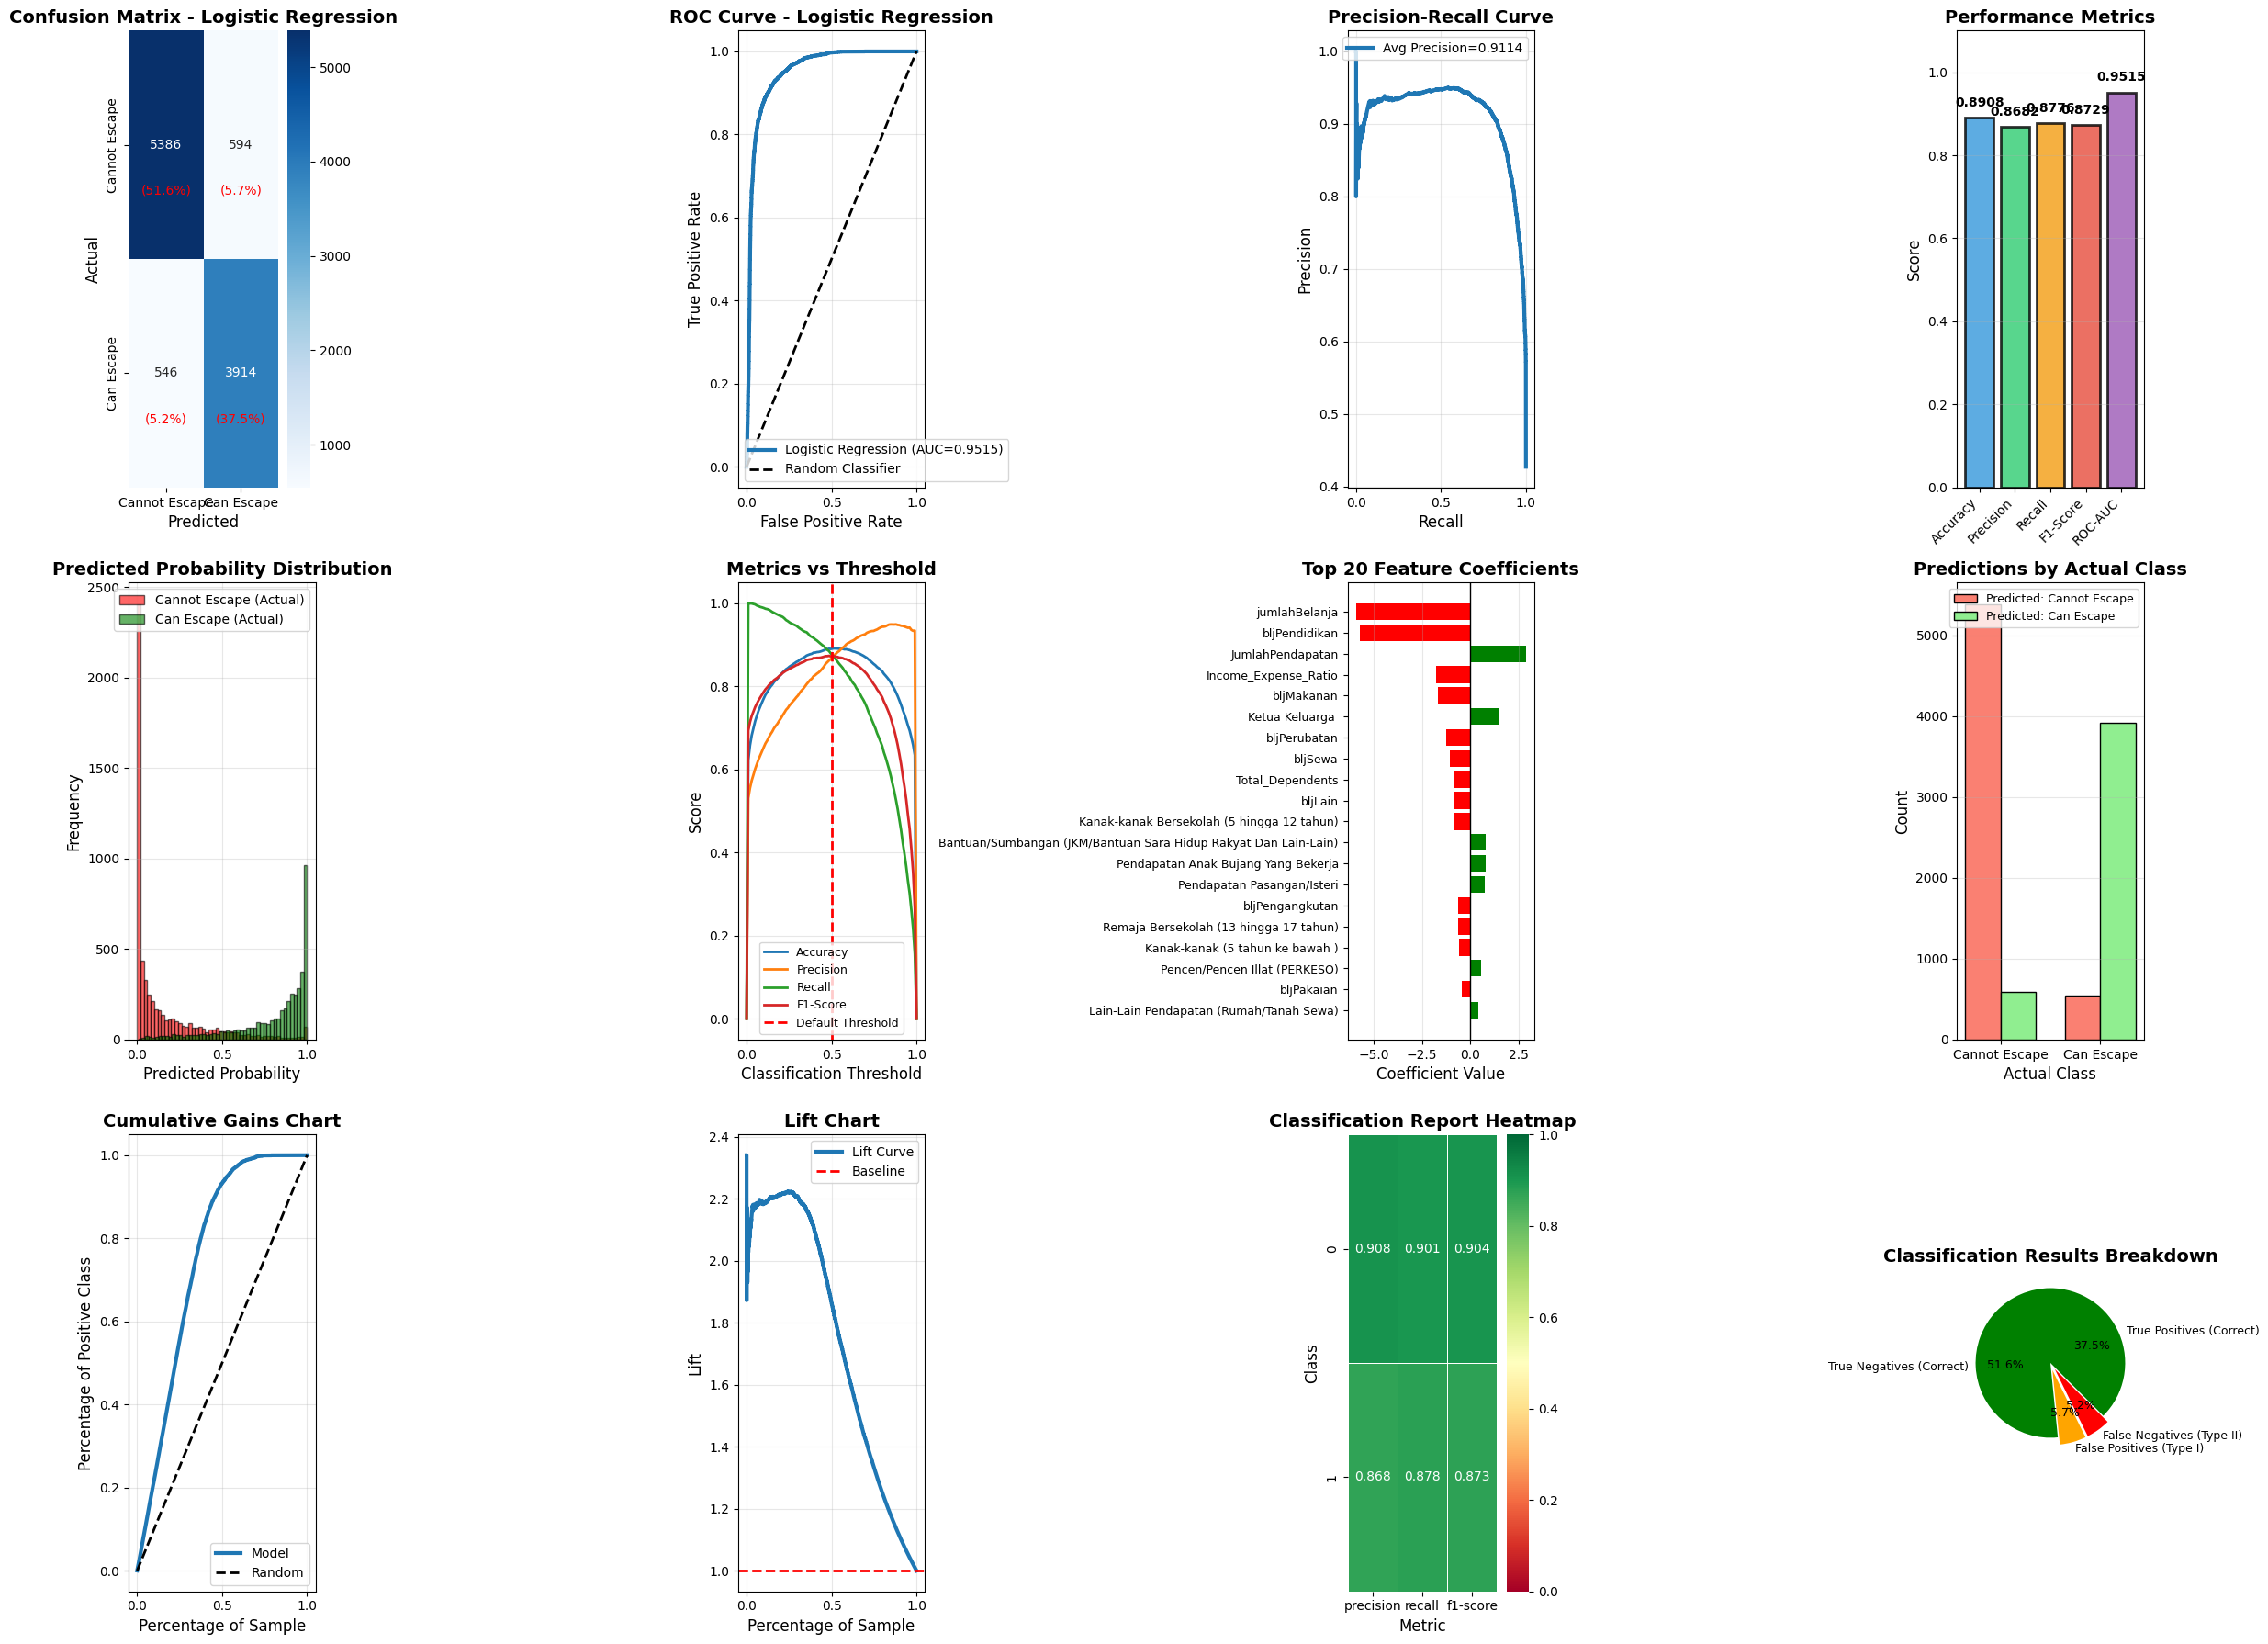


DETAILED LOGISTIC REGRESSION ANALYSIS

📊 CONFUSION MATRIX BREAKDOWN:
   True Negatives (Correct 'Cannot Escape'):  5,386 (51.59%)
   False Positives (Type I Error):            594 (5.69%)
   False Negatives (Type II Error):           546 (5.23%)
   True Positives (Correct 'Can Escape'):     3,914 (37.49%)

📈 MODEL PERFORMANCE:
   Accuracy:  0.8908 (89.08%)
   Precision: 0.8682 (86.82%)
   Recall:    0.8776 (87.76%)
   F1-Score:  0.8729 (87.29%)
   ROC-AUC:   0.9515 (95.15%)

🎯 ERROR ANALYSIS:
   Total Errors: 1,140 (10.92%)
   Type I Errors (False Positives):  594
   Type II Errors (False Negatives): 546
   Error Rate: 0.1092

🔍 TOP 10 MOST IMPORTANT FEATURES (by coefficient magnitude):
   22. jumlahBelanja: -5.9289 (Negative impact)
   18. bljPendidikan: -5.7103 (Negative impact)
   47. JumlahPendapatan: 2.8897 (Positive impact)
   60. Income_Expense_Ratio: -1.7541 (Negative impact)
   16. bljMakanan: -1.6701 (Negative impact)
   41. Ketua Keluarga : 1.5351 (Positive impact)
   20. b

In [13]:
# COMPREHENSIVE VISUALIZATION FOR LOGISTIC REGRESSION MODEL

print("="*100)
print("COMPREHENSIVE LOGISTIC REGRESSION MODEL VISUALIZATION")
print("="*100)

# Get Logistic Regression model and predictions
lr_model = results['Logistic Regression']['model']
lr_y_pred = results['Logistic Regression']['y_pred']
lr_y_pred_proba = results['Logistic Regression']['y_pred_proba']
lr_metrics = results['Logistic Regression']

# Create comprehensive visualization
fig = plt.figure(figsize=(24, 18))

# 1. Confusion Matrix
plt.subplot(3, 4, 1)
cm = confusion_matrix(y_test, lr_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=['Cannot Escape', 'Can Escape'],
            yticklabels=['Cannot Escape', 'Can Escape'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

# Add percentages
total = cm.sum()
for i in range(2):
    for j in range(2):
        plt.text(j+0.5, i+0.7, f'({cm[i,j]/total*100:.1f}%)', 
                ha='center', va='center', fontsize=10, color='red')

# 2. ROC Curve
plt.subplot(3, 4, 2)
fpr_lr, tpr_lr, thresholds = roc_curve(y_test, lr_y_pred_proba)
plt.plot(fpr_lr, tpr_lr, linewidth=3, label=f'Logistic Regression (AUC={lr_metrics["roc_auc"]:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# 3. Precision-Recall Curve
plt.subplot(3, 4, 3)
from sklearn.metrics import precision_recall_curve, average_precision_score
precision_vals, recall_vals, _ = precision_recall_curve(y_test, lr_y_pred_proba)
avg_precision = average_precision_score(y_test, lr_y_pred_proba)
plt.plot(recall_vals, precision_vals, linewidth=3, 
         label=f'Avg Precision={avg_precision:.4f}')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# 4. Model Performance Metrics Bar Chart
plt.subplot(3, 4, 4)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [lr_metrics['accuracy'], lr_metrics['precision'], 
                  lr_metrics['recall'], lr_metrics['f1'], lr_metrics['roc_auc']]
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
bars = plt.bar(metrics_names, metrics_values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
plt.ylim(0, 1.1)
plt.ylabel('Score', fontsize=12)
plt.title('Performance Metrics', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, metrics_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# 5. Predicted Probability Distribution
plt.subplot(3, 4, 5)
plt.hist(lr_y_pred_proba[y_test==0], bins=50, alpha=0.6, label='Cannot Escape (Actual)', 
         color='red', edgecolor='black')
plt.hist(lr_y_pred_proba[y_test==1], bins=50, alpha=0.6, label='Can Escape (Actual)', 
         color='green', edgecolor='black')
plt.xlabel('Predicted Probability', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Predicted Probability Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# 6. Classification Threshold Analysis
plt.subplot(3, 4, 6)
thresholds_to_test = np.linspace(0, 1, 100)
accuracies = []
precisions = []
recalls = []
f1_scores = []

for thresh in thresholds_to_test:
    y_pred_thresh = (lr_y_pred_proba >= thresh).astype(int)
    if len(np.unique(y_pred_thresh)) > 1:
        accuracies.append(accuracy_score(y_test, y_pred_thresh))
        precisions.append(precision_score(y_test, y_pred_thresh, zero_division=0))
        recalls.append(recall_score(y_test, y_pred_thresh, zero_division=0))
        f1_scores.append(f1_score(y_test, y_pred_thresh, zero_division=0))
    else:
        accuracies.append(0)
        precisions.append(0)
        recalls.append(0)
        f1_scores.append(0)

plt.plot(thresholds_to_test, accuracies, label='Accuracy', linewidth=2)
plt.plot(thresholds_to_test, precisions, label='Precision', linewidth=2)
plt.plot(thresholds_to_test, recalls, label='Recall', linewidth=2)
plt.plot(thresholds_to_test, f1_scores, label='F1-Score', linewidth=2)
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Default Threshold')
plt.xlabel('Classification Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Metrics vs Threshold', fontsize=14, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

# 7. Feature Coefficients (Top 20)
plt.subplot(3, 4, 7)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(20)

plt.barh(range(len(coefficients)), coefficients['Coefficient'], 
         color=['green' if x > 0 else 'red' for x in coefficients['Coefficient']])
plt.yticks(range(len(coefficients)), coefficients['Feature'], fontsize=9)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Top 20 Feature Coefficients', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# 8. Prediction Distribution by Actual Class
plt.subplot(3, 4, 8)
pred_by_actual = pd.DataFrame({
    'Actual': ['Cannot Escape', 'Cannot Escape', 'Can Escape', 'Can Escape'],
    'Predicted': ['Cannot Escape', 'Can Escape', 'Cannot Escape', 'Can Escape'],
    'Count': [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
})
colors_map = {'Cannot Escape': 'salmon', 'Can Escape': 'lightgreen'}
x = np.arange(2)
width = 0.35
plt.bar(x - width/2, [cm[0,0], cm[1,0]], width, label='Predicted: Cannot Escape', 
        color='salmon', edgecolor='black')
plt.bar(x + width/2, [cm[0,1], cm[1,1]], width, label='Predicted: Can Escape', 
        color='lightgreen', edgecolor='black')
plt.xlabel('Actual Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Predictions by Actual Class', fontsize=14, fontweight='bold')
plt.xticks(x, ['Cannot Escape', 'Can Escape'])
plt.legend(fontsize=9)
plt.grid(axis='y', alpha=0.3)

# 9. Cumulative Gains Chart
plt.subplot(3, 4, 9)
sorted_indices = np.argsort(lr_y_pred_proba)[::-1]
sorted_y_test = y_test.iloc[sorted_indices].values
cumulative_gains = np.cumsum(sorted_y_test) / np.sum(sorted_y_test)
percentile = np.arange(1, len(cumulative_gains) + 1) / len(cumulative_gains)
plt.plot(percentile, cumulative_gains, linewidth=3, label='Model')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
plt.xlabel('Percentage of Sample', fontsize=12)
plt.ylabel('Percentage of Positive Class', fontsize=12)
plt.title('Cumulative Gains Chart', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# 10. Lift Chart
plt.subplot(3, 4, 10)
baseline = np.sum(sorted_y_test) / len(sorted_y_test)
lift = cumulative_gains / (percentile + 1e-10)
plt.plot(percentile, lift, linewidth=3, label='Lift Curve')
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Baseline')
plt.xlabel('Percentage of Sample', fontsize=12)
plt.ylabel('Lift', fontsize=12)
plt.title('Lift Chart', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# 11. Classification Report Heatmap
plt.subplot(3, 4, 11)
from sklearn.metrics import classification_report
report_dict = classification_report(y_test, lr_y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :2].T
sns.heatmap(report_df, annot=True, fmt='.3f', cmap='RdYlGn', cbar=True, 
            vmin=0, vmax=1, linewidths=0.5)
plt.title('Classification Report Heatmap', fontsize=14, fontweight='bold')
plt.ylabel('Class', fontsize=12)
plt.xlabel('Metric', fontsize=12)

# 12. Error Analysis - Misclassified Samples
plt.subplot(3, 4, 12)
misclassified = (lr_y_pred != y_test)
error_types = pd.Series({
    'True Negatives (Correct)': cm[0,0],
    'False Positives (Type I)': cm[0,1],
    'False Negatives (Type II)': cm[1,0],
    'True Positives (Correct)': cm[1,1]
})
colors_error = ['green', 'orange', 'red', 'green']
explode = (0, 0.1, 0.1, 0)
plt.pie(error_types.values, labels=error_types.index, autopct='%1.1f%%', 
        colors=colors_error, explode=explode, startangle=90, 
        textprops={'fontsize': 9})
plt.title('Classification Results Breakdown', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Additional Statistics
print("\n" + "="*100)
print("DETAILED LOGISTIC REGRESSION ANALYSIS")
print("="*100)

print(f"\n📊 CONFUSION MATRIX BREAKDOWN:")
print(f"   True Negatives (Correct 'Cannot Escape'):  {cm[0,0]:,} ({cm[0,0]/cm.sum()*100:.2f}%)")
print(f"   False Positives (Type I Error):            {cm[0,1]:,} ({cm[0,1]/cm.sum()*100:.2f}%)")
print(f"   False Negatives (Type II Error):           {cm[1,0]:,} ({cm[1,0]/cm.sum()*100:.2f}%)")
print(f"   True Positives (Correct 'Can Escape'):     {cm[1,1]:,} ({cm[1,1]/cm.sum()*100:.2f}%)")

print(f"\n📈 MODEL PERFORMANCE:")
print(f"   Accuracy:  {lr_metrics['accuracy']:.4f} ({lr_metrics['accuracy']*100:.2f}%)")
print(f"   Precision: {lr_metrics['precision']:.4f} ({lr_metrics['precision']*100:.2f}%)")
print(f"   Recall:    {lr_metrics['recall']:.4f} ({lr_metrics['recall']*100:.2f}%)")
print(f"   F1-Score:  {lr_metrics['f1']:.4f} ({lr_metrics['f1']*100:.2f}%)")
print(f"   ROC-AUC:   {lr_metrics['roc_auc']:.4f} ({lr_metrics['roc_auc']*100:.2f}%)")

print(f"\n🎯 ERROR ANALYSIS:")
print(f"   Total Errors: {cm[0,1] + cm[1,0]:,} ({(cm[0,1] + cm[1,0])/cm.sum()*100:.2f}%)")
print(f"   Type I Errors (False Positives):  {cm[0,1]:,}")
print(f"   Type II Errors (False Negatives): {cm[1,0]:,}")
print(f"   Error Rate: {(cm[0,1] + cm[1,0])/cm.sum():.4f}")

print(f"\n🔍 TOP 10 MOST IMPORTANT FEATURES (by coefficient magnitude):")
top_features = coefficients.head(10)
for idx, row in top_features.iterrows():
    impact = "Positive" if row['Coefficient'] > 0 else "Negative"
    print(f"   {idx+1}. {row['Feature']}: {row['Coefficient']:.4f} ({impact} impact)")

print(f"\n✅ LOGISTIC REGRESSION VISUALIZATION COMPLETED!")
print("="*100)

In [14]:
from sklearn.model_selection import GridSearchCV

# hyperparameter tuning with GridSearchCV

# HYPERPARAMETER TUNING WITH GRIDSEARCHCV

print("="*100)
print("HYPERPARAMETER TUNING FOR ALL MODELS")
print("="*100)


# Define parameter grids for each model
param_grids = {
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000, 2000]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
}

# Store tuned models and results
tuned_results = {}

for model_name in models.keys():
    print(f"\n{'='*100}")
    print(f"🔧 TUNING {model_name.upper()}")
    print(f"{'='*100}")
    
    # Get base model
    base_model = models[model_name]
    param_grid = param_grids[model_name]
    
    print(f"\n📋 Parameter grid:")
    for param, values in param_grid.items():
        print(f"   - {param}: {values}")
    
    # Setup GridSearchCV
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    # Fit GridSearchCV
    print(f"\n⏳ Training with GridSearchCV (this may take a while)...")
    if model_name == 'Logistic Regression':
        grid_search.fit(X_train_scaled, y_train)
        y_pred_tuned = grid_search.predict(X_test_scaled)
        y_pred_proba_tuned = grid_search.predict_proba(X_test_scaled)[:, 1]
    else:
        grid_search.fit(X_train, y_train)
        y_pred_tuned = grid_search.predict(X_test)
        y_pred_proba_tuned = grid_search.predict_proba(X_test)[:, 1]
    
    # Get best parameters and score
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_
    
    print(f"\n✅ Best parameters found:")
    for param, value in best_params.items():
        print(f"   - {param}: {value}")
    print(f"\n✅ Best cross-validation F1-score: {best_score:.4f}")
    
    # Evaluate on test set
    accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
    precision_tuned = precision_score(y_test, y_pred_tuned)
    recall_tuned = recall_score(y_test, y_pred_tuned)
    f1_tuned = f1_score(y_test, y_pred_tuned)
    roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)
    
    print(f"\n📊 Test set performance (tuned model):")
    print(f"   - Accuracy:  {accuracy_tuned:.4f}")
    print(f"   - Precision: {precision_tuned:.4f}")
    print(f"   - Recall:    {recall_tuned:.4f}")
    print(f"   - F1-Score:  {f1_tuned:.4f}")
    print(f"   - ROC-AUC:   {roc_auc_tuned:.4f}")
    
    # Compare with baseline
    baseline_f1 = results[model_name]['f1']
    improvement = ((f1_tuned - baseline_f1) / baseline_f1) * 100
    
    print(f"\n📈 Improvement over baseline:")
    print(f"   - Baseline F1:  {baseline_f1:.4f}")
    print(f"   - Tuned F1:     {f1_tuned:.4f}")
    print(f"   - Improvement:  {improvement:+.2f}%")
    
    # Store results
    tuned_results[model_name] = {
        'model': grid_search.best_estimator_,
        'best_params': best_params,
        'cv_score': best_score,
        'accuracy': accuracy_tuned,
        'precision': precision_tuned,
        'recall': recall_tuned,
        'f1': f1_tuned,
        'roc_auc': roc_auc_tuned,
        'y_pred': y_pred_tuned,
        'y_pred_proba': y_pred_proba_tuned,
        'improvement': improvement
    }

# Final comparison
print(f"\n{'='*100}")
print("FINAL MODEL COMPARISON (BASELINE VS TUNED)")
print(f"{'='*100}")

comparison_tuned = pd.DataFrame({
    'Model': list(tuned_results.keys()),
    'Baseline_F1': [results[m]['f1'] for m in tuned_results.keys()],
    'Tuned_F1': [tuned_results[m]['f1'] for m in tuned_results.keys()],
    'Improvement_%': [tuned_results[m]['improvement'] for m in tuned_results.keys()],
    'Tuned_Accuracy': [tuned_results[m]['accuracy'] for m in tuned_results.keys()],
    'Tuned_ROC_AUC': [tuned_results[m]['roc_auc'] for m in tuned_results.keys()]
})

print("\n" + comparison_tuned.to_string(index=False))

# Select best tuned model
best_tuned_model_name = comparison_tuned.loc[comparison_tuned['Tuned_F1'].idxmax(), 'Model']
best_tuned_model = tuned_results[best_tuned_model_name]['model']

print(f"\n🏆 BEST TUNED MODEL: {best_tuned_model_name}")
print(f"   - F1-Score: {tuned_results[best_tuned_model_name]['f1']:.4f}")
print(f"   - ROC-AUC:  {tuned_results[best_tuned_model_name]['roc_auc']:.4f}")
print(f"   - Improvement: {tuned_results[best_tuned_model_name]['improvement']:+.2f}%")

print(f"\n✅ HYPERPARAMETER TUNING COMPLETED!")
print(f"{'='*100}")

HYPERPARAMETER TUNING FOR ALL MODELS

🔧 TUNING LOGISTIC REGRESSION

📋 Parameter grid:
   - C: [0.001, 0.01, 0.1, 1, 10, 100]
   - penalty: ['l1', 'l2']
   - solver: ['liblinear', 'saga']
   - max_iter: [1000, 2000]

⏳ Training with GridSearchCV (this may take a while)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

✅ Best parameters found:
   - C: 0.1
   - max_iter: 1000
   - penalty: l1
   - solver: liblinear

✅ Best cross-validation F1-score: 0.8687

📊 Test set performance (tuned model):
   - Accuracy:  0.8912
   - Precision: 0.8687
   - Recall:    0.8780
   - F1-Score:  0.8733
   - ROC-AUC:   0.9516

📈 Improvement over baseline:
   - Baseline F1:  0.8729
   - Tuned F1:     0.8733
   - Improvement:  +0.05%

🔧 TUNING RANDOM FOREST

📋 Parameter grid:
   - n_estimators: [50, 100, 200]
   - max_depth: [10, 20, 30, None]
   - min_samples_split: [2, 5, 10]
   - min_samples_leaf: [1, 2, 4]
   - max_features: ['sqrt', 'log2']

⏳ Training with GridSearchCV (this may take a w